# 🐦 Bird Sound Classifier
### Lightweight CNN on Mel-Spectrograms — 114 Species

**Architecture:** MobileNet-style depthwise-separable CNN  
**Input:** Log-Mel Spectrogram (128 × 128)  
**Dataset:** [Kaggle — Sound of 114 Species of Birds till 2022](https://www.kaggle.com/datasets/soumendraprasad/sound-of-114-species-of-birds-till-2022)

---
**Runtime:** Set to `GPU → T4` for fastest training  
**Expected training time:** ~20–40 min on T4 depending on dataset size

## 1️⃣ Install & Import Dependencies

In [1]:
# Install kagglehub if not present
!pip install kagglehub librosa -q

In [2]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 2️⃣ Download Dataset from Kaggle

In [3]:
# ─────────────────────────────────────────────────────────────
# Option A: Using kagglehub (recommended)
# ─────────────────────────────────────────────────────────────
import kagglehub

path = kagglehub.dataset_download("soumendraprasad/sound-of-114-species-of-birds-till-2022")
print("Dataset path:", path)

DATA_ROOT = Path(path)

100%|██████████| 2.06G/2.06G [00:25<00:00, 87.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/soumendraprasad/sound-of-114-species-of-birds-till-2022/versions/1


In [4]:
# Explore dataset structure
print("Top-level contents:")
for item in sorted(DATA_ROOT.iterdir()):
    print(f"  {item.name}")

Top-level contents:
  Birds Voice.csv
  Voice of Birds


## 3️⃣ Build File Index

In [5]:
AUDIO_EXTENSIONS = {'.mp3', '.wav', '.ogg', '.flac', '.m4a'}

records = []
for audio_file in DATA_ROOT.rglob('*'):
    if audio_file.suffix.lower() in AUDIO_EXTENSIONS:
        # Use the immediate parent folder as the species label
        label = audio_file.parent.name
        records.append({'path': str(audio_file), 'label': label})

df = pd.DataFrame(records)
print(f"Total audio files : {len(df)}")
print(f"Unique species    : {df['label'].nunique()}")
print()
print("Samples per class (top 10):")
print(df['label'].value_counts().head(10))

Total audio files : 2161
Unique species    : 114

Samples per class (top 10):
label
Little Chachalaca_sound           30
Red-winged Tinamou_sound          30
Cinereous Tinamou_sound           30
Andean Tinamou_sound              30
Grey-headed Chachalaca_sound      30
Dusky Megapode_sound              30
Plain Chachalaca_sound            30
Orange-footed Scrubfowl_sound     30
Rufous-vented Chachalaca_sound    30
Variegated Tinamou_sound          30
Name: count, dtype: int64


In [6]:
# ── Optional: cap per-class samples to speed up training ──────
MAX_PER_CLASS = 100   # set None to use everything

if MAX_PER_CLASS:
    df = (df.groupby('label', group_keys=False)
            .apply(lambda x: x.sample(min(len(x), MAX_PER_CLASS), random_state=42)))
    df = df.reset_index(drop=True)
    print(f"After capping: {len(df)} files | {df['label'].nunique()} classes")

# Encode labels
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)
print(f"Number of classes: {NUM_CLASSES}")

After capping: 2161 files | 114 classes
Number of classes: 114


## 4️⃣ Audio → Mel-Spectrogram Feature Extraction

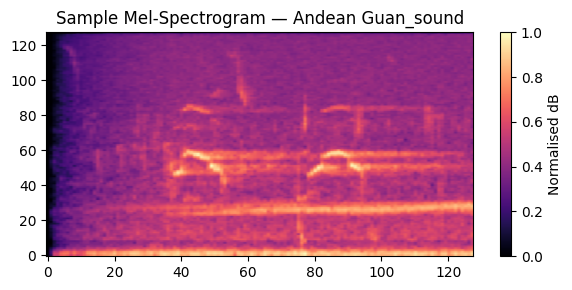

In [7]:
# ─── Config ───────────────────────────────────────────────────
SR          = 22050   # sample rate
DURATION    = 5       # seconds to use per clip
N_MELS      = 128
N_FFT       = 1024
HOP_LENGTH  = 512
IMG_SIZE    = 128     # final spectrogram image size (square)
# ──────────────────────────────────────────────────────────────

def load_mel(path, sr=SR, duration=DURATION,
             n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH,
             img_size=IMG_SIZE):
    """Load audio, compute log-Mel spectrogram, resize to img_size×img_size."""
    try:
        y, _ = librosa.load(path, sr=sr, duration=duration, mono=True)
        # Pad if shorter than requested duration
        target_len = sr * duration
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
        log_mel = librosa.power_to_db(mel, ref=np.max)  # shape: (n_mels, T)

        # Resize to square via simple interpolation
        from PIL import Image
        img = Image.fromarray(log_mel)
        img = img.resize((img_size, img_size), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32)

        # Normalise to [0, 1]
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        return arr
    except Exception:
        return None

# Quick visual check
sample_path = df.iloc[0]['path']
mel_sample = load_mel(sample_path)
plt.figure(figsize=(6, 3))
plt.imshow(mel_sample, origin='lower', aspect='auto', cmap='magma')
plt.title(f'Sample Mel-Spectrogram — {df.iloc[0]["label"]}')
plt.colorbar(label='Normalised dB')
plt.tight_layout()
plt.show()

## 5️⃣ PyTorch Dataset & DataLoaders

In [10]:
# Drop classes with fewer than 3 samples
class_counts = df['label_id'].value_counts()
valid_ids = class_counts[class_counts >= 3].index
df = df[df['label_id'].isin(valid_ids)].reset_index(drop=True)

# Re-encode labels so IDs are contiguous after filtering
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)

In [12]:
class BirdSoundDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths   = paths
        self.labels  = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        mel = load_mel(self.paths[idx])
        if mel is None:                        # fallback: silent clip
            mel = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
        # Shape: (1, H, W) — single-channel
        mel = torch.tensor(mel).unsqueeze(0)
        if self.transform:
            mel = self.transform(mel)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label



# Train / val / test split  80 / 10 / 10
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label_id'], random_state=42)

# Filter temp_df to remove classes with only 1 sample before the second split
temp_class_counts = temp_df['label_id'].value_counts()
valid_temp_ids = temp_class_counts[temp_class_counts >= 2].index
temp_df_filtered = temp_df[temp_df['label_id'].isin(valid_temp_ids)].reset_index(drop=True)

val_df,   test_df = train_test_split(temp_df_filtered, test_size=0.5, stratify=temp_df_filtered['label_id'], random_state=42)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

# Light data augmentation on training set (time/freq masking)
train_transform = transforms.Compose([
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),  # simulate SpecAugment
])

BATCH_SIZE = 64

train_ds = BirdSoundDataset(train_df['path'].tolist(), train_df['label_id'].tolist(), transform=train_transform)
val_ds   = BirdSoundDataset(val_df['path'].tolist(),   val_df['label_id'].tolist())
test_ds  = BirdSoundDataset(test_df['path'].tolist(),  test_df['label_id'].tolist())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")

Train: 1720  Val: 205  Test: 206
Train batches: 27


## 6️⃣ Lightweight Model — MobileNet-Style CNN

In [14]:
class DepthwiseSepConv(nn.Module):
    """Depthwise-separable conv block (MobileNet building block)."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU6(inplace=True),
        )
        self.pw = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU6(inplace=True),
        )

    def forward(self, x):
        return self.pw(self.dw(x))


class LightBirdNet(nn.Module):
    """
    Lightweight bird classifier.
    Input : (B, 1, 128, 128)  — single-channel log-Mel
    Output: (B, num_classes)
    Params: ~350 K
    """
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True),
        )  # → 32×64×64

        self.blocks = nn.Sequential(
            DepthwiseSepConv(32,  64, stride=1),   # 64×64×64
            DepthwiseSepConv(64,  128, stride=2),  # 128×32×32
            DepthwiseSepConv(128, 128, stride=1),
            DepthwiseSepConv(128, 256, stride=2),  # 256×16×16
            DepthwiseSepConv(256, 256, stride=1),
            DepthwiseSepConv(256, 512, stride=2),  # 512×8×8
            *[DepthwiseSepConv(512, 512, stride=1) for _ in range(3)],
            DepthwiseSepConv(512, 512, stride=2),  # 512×4×4
        )

        self.pool = nn.AdaptiveAvgPool2d(1)         # 512×1×1
        self.drop = nn.Dropout(0.3)
        self.fc   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.pool(x).flatten(1)
        x = self.drop(x)
        return self.fc(x)


model = LightBirdNet(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 1,398,635
LightBirdNet(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (blocks): Sequential(
    (0): DepthwiseSepConv(
      (dw): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (pw): Sequential(
        (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
    )
    (1): DepthwiseSepConv(
      (dw): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
        (1): BatchNorm2d(

## 7️⃣ Training Setup

In [15]:
EPOCHS    = 30
LR        = 3e-3
PATIENCE  = 7     # early stopping patience

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_loader), epochs=EPOCHS,
    pct_start=0.1)

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            if training:
                optimizer.zero_grad()
            logits = model(X)
            loss   = criterion(logits, y)
            if training:
                loss.backward()
                optimizer.step()
                scheduler.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total

print("Training config ready.")

Training config ready.


## 8️⃣ Train the Model

In [17]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
patience_counter = 0
CKPT_PATH = 'best_bird_model.pth'

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)
        patience_counter = 0
        flag = ' ✅ saved'
    else:
        patience_counter += 1

    print(f"Epoch {epoch:03d}/{EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}{flag}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 001/30  train_loss=4.4431  train_acc=0.0953  val_loss=4.5771  val_acc=0.0146 ✅ saved
Epoch 002/30  train_loss=4.0093  train_acc=0.2000  val_loss=3.8850  val_acc=0.2000 ✅ saved
Epoch 003/30  train_loss=3.4607  train_acc=0.2948  val_loss=3.9537  val_acc=0.1756
Epoch 004/30  train_loss=2.8578  train_acc=0.4372  val_loss=3.2440  val_acc=0.3707 ✅ saved
Epoch 005/30  train_loss=2.3836  train_acc=0.5669  val_loss=3.0461  val_acc=0.4537 ✅ saved
Epoch 006/30  train_loss=2.1155  train_acc=0.6320  val_loss=3.1230  val_acc=0.4488
Epoch 007/30  train_loss=1.8132  train_acc=0.7564  val_loss=2.7531  val_acc=0.5317 ✅ saved
Epoch 008/30  train_loss=1.6153  train_acc=0.7994  val_loss=2.3794  val_acc=0.6098 ✅ saved
Epoch 009/30  train_loss=1.4486  train_acc=0.8576  val_loss=2.3914  val_acc=0.5951
Epoch 010/30  train_loss=1.3454  train_acc=0.9017  val_loss=2.3263  val_acc=0.6341 ✅ saved
Epoch 011/30  train_loss=1.2627  train_acc=0.9227  val_loss=2.2335  val_acc=0.6488 ✅ saved
Epoch 012/30  train_los

## 9️⃣ Training Curves

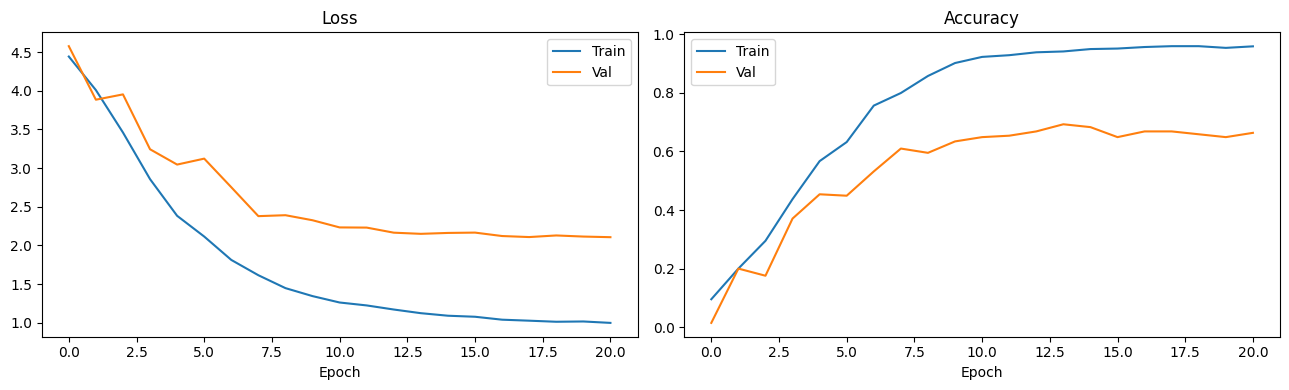

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 🔟 Evaluate on Test Set

In [19]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))

test_loss, test_acc = run_epoch(test_loader, training=False)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Loss: 2.2650
Test Accuracy: 66.99%


In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        preds = model(X).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Get the unique labels present in the test set true labels
unique_labels_in_test_set = np.unique(all_labels)

# Map these unique labels back to their original names using the label encoder
# This ensures that target_names only includes names for classes actually present in all_labels
target_names_for_report = le.classes_[unique_labels_in_test_set]

# Classification report
print(classification_report(all_labels, all_preds,
                            labels=unique_labels_in_test_set,
                            target_names=target_names_for_report))

                                  precision    recall  f1-score   support

               Andean Guan_sound       0.40      0.67      0.50         3
            Andean Tinamou_sound       0.50      0.33      0.40         3
    Australian Brushturkey_sound       0.67      0.67      0.67         3
          Band-tailed Guan_sound       0.50      0.33      0.40         3
         Bartletts Tinamou_sound       0.67      0.67      0.67         3
                Baudo Guan_sound       0.00      0.00      0.00         1
              Bearded Guan_sound       0.25      0.33      0.29         3
        Berlepschs Tinamou_sound       1.00      1.00      1.00         2
            Biak Scrubfowl_sound       1.00      1.00      1.00         1
             Black Tinamou_sound       0.00      0.00      0.00         2
  Black-billed Brushturkey_sound       1.00      0.50      0.67         2
      Black-capped Tinamou_sound       0.00      0.00      0.00         3
 Black-fronted Piping Guan_sound     

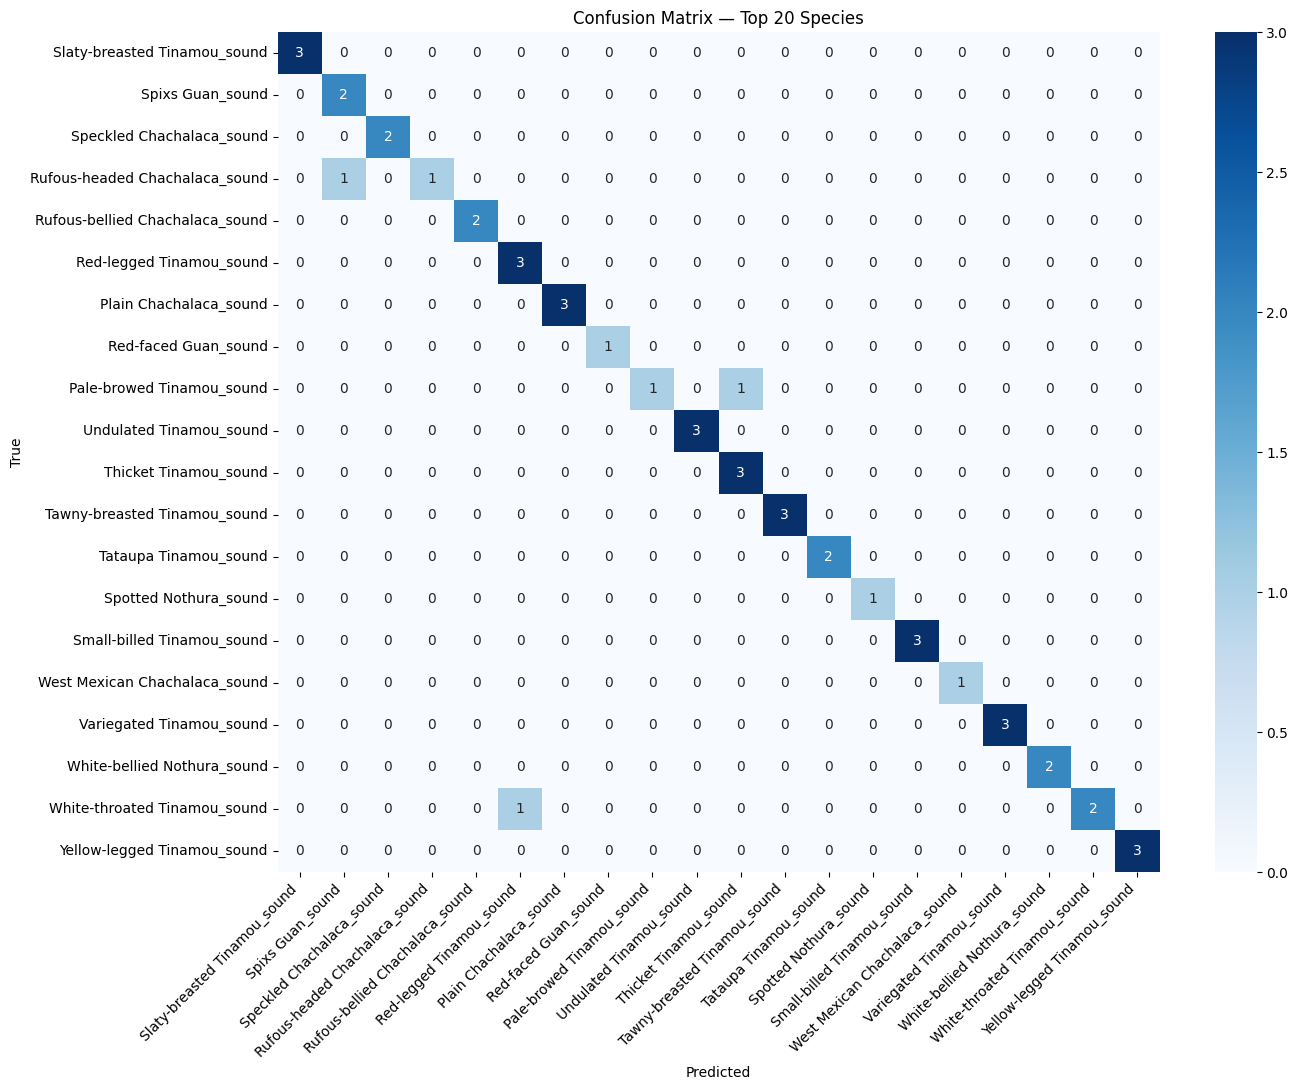

In [21]:
# Confusion matrix — top-20 classes for readability
top_k = 20
top_classes = np.argsort(np.bincount(all_labels))[-top_k:]

mask = np.isin(all_labels, top_classes)
cm = confusion_matrix(all_labels[mask], all_preds[mask], labels=top_classes)

plt.figure(figsize=(14, 11))
sns.heatmap(cm, xticklabels=le.classes_[top_classes],
            yticklabels=le.classes_[top_classes],
            fmt='d', cmap='Blues', annot=True)
plt.title(f'Confusion Matrix — Top {top_k} Species')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 1️⃣1️⃣ Inference on a New Audio File

In [22]:
def predict_bird(audio_path, top_k=5):
    """Predict top-k species from an audio file path."""
    mel = load_mel(audio_path)
    if mel is None:
        print('Could not load audio file.')
        return

    x = torch.tensor(mel).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,H,W)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = F.softmax(logits, dim=1).cpu().numpy()[0]

    top_idx  = probs.argsort()[::-1][:top_k]
    top_prob = probs[top_idx]
    top_name = le.classes_[top_idx]

    print(f"Predictions for: {Path(audio_path).name}")
    print("-" * 40)
    for name, prob in zip(top_name, top_prob):
        bar = '█' * int(prob * 30)
        print(f"{name:<35} {prob*100:5.1f}%  {bar}")

# ── Test with any file from the dataset ──
sample = random.choice(df['path'].tolist())
true_label = df.loc[df['path'] == sample, 'label'].values[0]
print(f"True label: {true_label}\n")
predict_bird(sample)

True label: Crested Guan_sound

Predictions for: Crested Guan8.mp3
----------------------------------------
Crested Guan_sound                   95.8%  ████████████████████████████
Rufous-vented Chachalaca_sound        0.6%  
Spixs Guan_sound                      0.4%  
Red-faced Guan_sound                  0.3%  
Chaco Chachalaca_sound                0.2%  


## 1️⃣2️⃣ Save & Export

In [24]:
import pickle

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save model config alongside weights
torch.save({
    'state_dict' : model.state_dict(),
    'num_classes': NUM_CLASSES,
    'classes'    : list(le.classes_),
    'img_size'   : IMG_SIZE,
    'sr'         : SR,
    'duration'   : DURATION,
}, 'bird_classifier_full.pth')

print('Saved: bird_classifier_full.pth  &  label_encoder.pkl')

# Download from Colab
try:
    from google.colab import files
    files.download('bird_classifier_full.pth')
    files.download('label_encoder.pkl')
    files.download('training_curves.png')
except ImportError:
    print('(Not in Colab — skipping download step)')

Saved: bird_classifier_full.pth  &  label_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import os
from pathlib import Path

# Reload the model and label encoder if not already in memory or if the session restarted
try:
    # Check if key components are already defined or available
    # if 'model' not in locals() or 'le' not in locals() or 'device' not in locals():
    import torch
    import pickle
    import torch.nn as nn
    import torch.nn.functional as F # Required for F.softmax in predict_bird

    # Ensure the model class is defined (from previous cells) for robustness
    class DepthwiseSepConv(nn.Module):
        """Depthwise-separable conv block (MobileNet building block)."""
        def __init__(self, in_ch, out_ch, stride=1):
            super().__init__()
            self.dw = nn.Sequential(
                nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
                nn.BatchNorm2d(in_ch),
                nn.ReLU6(inplace=True),
            )
            self.pw = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU6(inplace=True),
            )

        def forward(self, x):
            return self.pw(self.dw(x))


    class LightBirdNet(nn.Module):
        """
        Lightweight bird classifier.
        Input : (B, 1, 128, 128)  — single-channel log-Mel
        Output: (B, num_classes)
        Params: ~350 K
        """
        def __init__(self, num_classes):
            super().__init__()
            self.stem = nn.Sequential(
                nn.Conv2d(1, 32, 3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(32),
                nn.ReLU6(inplace=True),
            )  # → 32×64×64

            self.blocks = nn.Sequential(
                DepthwiseSepConv(32,  64, stride=1),   # 64×64×64
                DepthwiseSepConv(64,  128, stride=2),  # 128×32×32
                DepthwiseSepConv(128, 128, stride=1),
                DepthwiseSepConv(128, 256, stride=2),  # 256×16×16
                DepthwiseSepConv(256, 256, stride=1),
                DepthwiseSepConv(256, 512, stride=2),  # 512×8×8
                *[DepthwiseSepConv(512, 512, stride=1) for _ in range(3)],
                DepthwiseSepConv(512, 512, stride=2),  # 512×4×4
            )

            self.pool = nn.AdaptiveAvgPool2d(1)         # 512×1×1
            self.drop = nn.Dropout(0.3)
            self.fc   = nn.Linear(512, num_classes)

        def forward(self, x):
            x = self.stem(x)
            x = self.blocks(x)
            x = self.pool(x).flatten(1)
            x = self.drop(x)
            return self.fc(x)

    # Assuming device is already defined (cuda or cpu) from previous cells
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load label encoder
    with open('label_encoder.pkl', 'rb') as f:
        le = pickle.load(f)

    # Load model checkpoint and configuration
    checkpoint = torch.load('bird_classifier_full.pth', map_location=device)
    NUM_CLASSES = checkpoint['num_classes']
    IMG_SIZE = checkpoint['img_size']
    SR = checkpoint['sr']
    DURATION = checkpoint['duration']

    model = LightBirdNet(NUM_CLASSES).to(device)
    model.load_state_dict(checkpoint['state_dict'])
    model.eval() # Set model to evaluation mode
    print("Model and LabelEncoder loaded successfully for GUI.")

except Exception as e:
    print(f"Could not load model/label_encoder. Please ensure previous cells were run and artifacts exist. Error: {e}")
    # If loading fails, subsequent parts of the GUI might not work correctly.

# Define load_mel and predict_bird here for robustness if kernel is restarted
# and only this cell is executed, assuming librosa is installed.

def load_mel(path, sr=SR, duration=DURATION,
             n_mels=128, n_fft=1024, hop_length=512,
             img_size=IMG_SIZE):
    """Load audio, compute log-Mel spectrogram, resize to img_size×img_size."""
    try:
        y, _ = librosa.load(path, sr=sr, duration=duration, mono=True)
        # Pad if shorter than requested duration
        target_len = sr * duration
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
        log_mel = librosa.power_to_db(mel, ref=np.max)  # shape: (n_mels, T)

        # Resize to square via simple interpolation
        from PIL import Image
        img = Image.fromarray(log_mel)
        img = img.resize((img_size, img_size), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32)

        # Normalise to [0, 1]
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        return arr
    except Exception as e:
        print(f"Error loading mel spectrogram from {path}: {e}")
        return None

def predict_bird(audio_path, top_k=5):
    """Predict top-k species from an audio file path."""
    mel = load_mel(audio_path)
    if mel is None:
        print('Could not load or process audio file.')
        return

    # Add batch and channel dimensions: (1, 1, H, W)
    x = torch.tensor(mel).unsqueeze(0).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = F.softmax(logits, dim=1).cpu().numpy()[0]

    top_idx  = probs.argsort()[::-1][:top_k]
    top_prob = probs[top_idx]
    top_name = le.classes_[top_idx]

    print(f"Predictions for: {Path(audio_path).name}")
    print("-" * 40)
    for name, prob in zip(top_name, top_prob):
        bar = '█' * int(prob * 30)
        print(f"{name:<35} {prob*100:5.1f}%  {bar}")


# GUI Components
uploader = widgets.FileUpload(
    accept='audio/*',  # Accepted file types
    multiple=False,    # Only allow one file to be uploaded
    description='Upload Audio File',
    layout=widgets.Layout(width='auto', height='auto')
)

top_k_slider = widgets.IntSlider(
    value=5,
    min=1,
    max=min(10, NUM_CLASSES if 'NUM_CLASSES' in globals() else 10), # Cap max top_k to 10 or NUM_CLASSES
    step=1,
    description='Top K Predictions:',
    continuous_update=False
)

output_widget = widgets.Output()

# Function to handle prediction
def on_predict_button_clicked(b):
    with output_widget:
        clear_output()
        if not uploader.value:
            print("Please upload an audio file first.")
            return

        # Get the uploaded file
        uploaded_filename = next(iter(uploader.value))
        uploaded_file_content = uploader.value[uploaded_filename]['content']

        # Save to a temporary file
        temp_audio_path = Path("/tmp") / uploaded_filename
        try:
            with open(temp_audio_path, 'wb') as f:
                f.write(uploaded_file_content)
            predict_bird(str(temp_audio_path), top_k=top_k_slider.value)
        except Exception as e:
            print(f"Error during prediction: {e}")
        finally:
            # Clean up the temporary file
            if temp_audio_path.exists():
                os.remove(temp_audio_path)

predict_button = widgets.Button(description="Predict Species")
predict_button.on_click(on_predict_button_clicked)

# Display GUI
display(uploader, top_k_slider, predict_button, output_widget)


Model and LabelEncoder loaded successfully for GUI.


FileUpload(value={}, accept='audio/*', description='Upload Audio File', layout=Layout(height='auto', width='au…

IntSlider(value=5, continuous_update=False, description='Top K Predictions:', max=10, min=1)

Button(description='Predict Species', style=ButtonStyle())

Output()

---
## 💡 Tips & Next Steps

| Idea | How |
|------|-----|
| **More accuracy** | Replace stem with pretrained `EfficientNet-B0` or `MobileNetV3` (torchvision) |
| **SpecAugment** | Add `torchaudio.transforms.FrequencyMasking` + `TimeMasking` |
| **Mixup** | Mix two spectrograms + labels in the training loop |
| **Longer clips** | Increase `DURATION` to 10 s |
| **TFLite export** | `torch.jit.trace` → ONNX → TFLite for mobile |
| **Grad-CAM** | Visualise which frequency bands drive the prediction |
